> **Snap Market model series.** We start from Carl's baseline momentum model and iterate to test it and improve it.
>
> **Notebook 10 — the business view.** With elastic demand (better odds draw more volume), compare which model makes the most net house PnL, and show how the answer depends on demand elasticity.

# 10 — Which model makes the most money, and how it depends on demand elasticity

Profit = house edge times volume, and volume depends on how competitive the odds are. We compare
**every model** under **elastic demand** (`demand_responsive_pool`: tighter odds draw more
volume) with the two expected-value-gated arbitrageurs (predictive, regime-aware) betting inside
the pool, and read off the **net house PnL**.

The one free assumption is the **demand elasticity** — how strongly volume reacts to the offered
margin. We do not know it, so we sweep it from 2 to 32. The vig-only models (`momentum_lookup`,
`momentum_lookup_rolling`, `volatility_regime_momentum`, `momentum_logistic_rolling`) quote the
same margin, so they are roughly flat in elasticity; only the extra-margin models
(`hidden_symmetric_margin` / model 3, and `guarded_volatility_regime_momentum`) lose volume as
elasticity rises.

In [1]:
import os
import sys

# Move up one level to the project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
# Add the new current directory to the Python path
sys.path.insert(0, os.getcwd())

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Net house PnL was pre-computed per (model, elasticity); see the regenerate cell at the bottom.
sweep = pd.read_csv("notebooks/assets/10_elasticity_sweep.csv", index_col="elasticity")
model_order = list(sweep.columns)
x_low, x_high = sweep.values.min() * 0.97, sweep.values.max() * 1.02

def plot_for_elasticity(elasticity=8, ax=None):
    values = sweep.loc[elasticity, model_order]
    best = values.idxmax()
    colors = ["#dc2626" if model == best else "#2563eb" for model in model_order]
    own_axes = ax is None
    if own_axes:
        _, ax = plt.subplots(figsize=(9, 4.5))
    ax.barh(model_order, values.values, color=colors)
    ax.invert_yaxis()
    ax.set_title(f"demand elasticity = {elasticity} (best in red)")
    ax.set_xlabel("net house PnL")
    ax.set_xlim(x_low, x_high)
    if own_axes:
        plt.tight_layout(); plt.show()

sweep.round(0)

,momentum_lookup,momentum_lookup_rolling,volatility_regime_momentum,momentum_logistic_rolling,hidden_symmetric_margin,guarded_volatility_regime_momentum
elasticity,,,,,,
2,26331.0,26298.0,26278.0,25575.0,28004.0,26488.0
3,26331.0,26298.0,26278.0,25576.0,27572.0,26342.0
4,26331.0,26298.0,26278.0,25576.0,27178.0,26210.0
5,26331.0,26298.0,26278.0,25576.0,26812.0,26090.0
6,26331.0,26298.0,26278.0,25576.0,26487.0,25980.0
7,26331.0,26298.0,26278.0,25577.0,26198.0,25879.0
8,26331.0,26298.0,26278.0,25577.0,25931.0,25787.0
9,26331.0,26298.0,26278.0,25577.0,25684.0,25701.0
10,26331.0,26298.0,26278.0,25577.0,25458.0,25622.0


## Static comparison (always visible)

Net house PnL by model at three elasticities. Watch model 3 go from best (low elasticity) to worst
(high elasticity), while the vig-only models barely move.

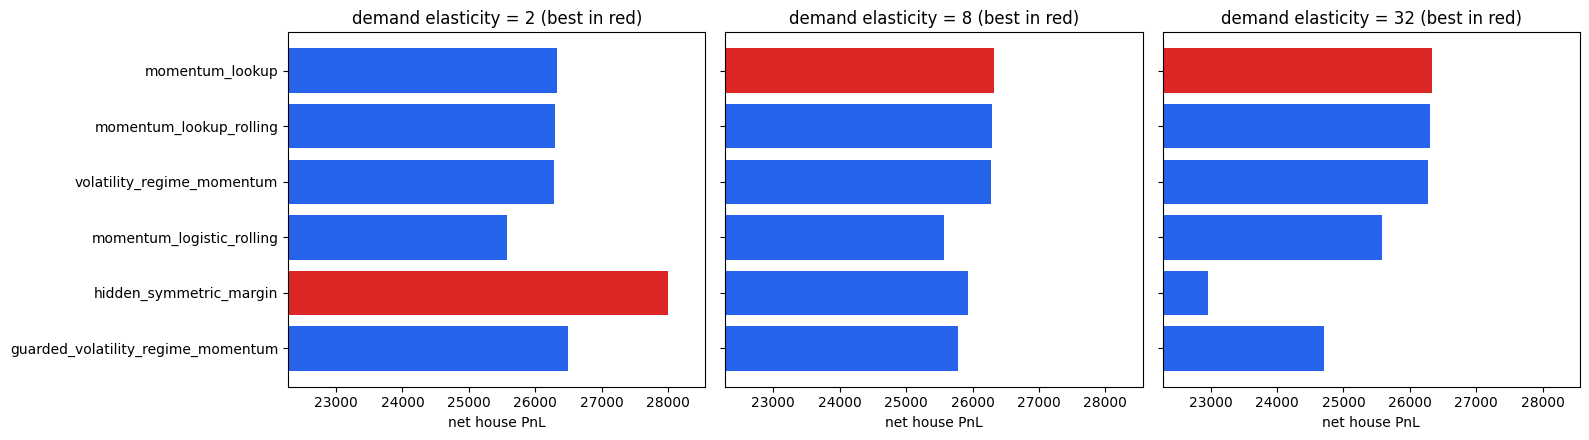

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, elasticity in zip(axes, [2, 8, 32]):
    plot_for_elasticity(elasticity, ax=ax)
plt.tight_layout(); plt.show()

## Interactive slider

Drag the elasticity from 2 to 32 and the bars update instantly (the data is pre-computed).
`pip install ipywidgets` if the slider does not appear (the static charts above still show the result).

In [4]:
try:
    import ipywidgets as widgets
    widgets.interact(plot_for_elasticity,
                     elasticity=widgets.IntSlider(min=2, max=32, step=1, value=8,
                                                  description="elasticity"),
                     ax=widgets.fixed(None))
except ImportError:
    print("ipywidgets not installed; see the static comparison above.")

ipywidgets not installed; see the static comparison above.


## What the comparison shows

- The four **vig-only** models are flat in elasticity and clustered around 25.6k-26.3k net PnL.
- **Model 3 swings the most.** At **low elasticity (2)** it is the **best** (~28.0k): demand barely
  reacts to its wider margin, so it keeps volume *and* collects more vig. As elasticity rises its
  volume collapses and it becomes the **worst** (~23.0k at 32). The crossover is around elasticity 7-9.
- The **guarded** model declines mildly with elasticity, staying close to the vig-only cluster.

**Takeaway.** Which model maximises profit depends on how price-sensitive the clients are:
- **Inelastic demand** (clients do not shop on odds) -> the defensive high-margin model 3 wins.
- **Elastic demand** (clients chase the best odds) -> the competitive direction-pricing models win,
  and over-charging (model 3) is the worst choice.

This is why the elasticity is the number to **calibrate from real data**: it decides the whole
pricing strategy.

## How the sweep was computed (reproduce)

For each elasticity, each model is run through `simulate` with an elastic `demand_responsive_pool`
plus the predictive and regime-aware arbitrageurs; the base stake is calibrated once so a vig-only
model trades ~200,000 over the window. The cell below regenerates the CSV (a few minutes).

In [5]:
# Regenerate the sweep (slow). Skip if you only want the charts above.
REGENERATE = False

if REGENERATE:
    from snapmarket.data import load_oracle_prices
    from snapmarket.features import build_features
    from snapmarket.parameters import SharedParameters
    from snapmarket.models import build_model
    from snapmarket.experiments import common_evaluation_start
    from snapmarket.signals import walk_forward_logistic_probability, regime_conditional_probability
    from snapmarket.strategies import demand_responsive_pool, predictive_bettor, regime_aware_bettor
    from snapmarket.engine import simulate

    shared = SharedParameters()
    features = build_features(load_oracle_prices(), shared)
    names = ["momentum_lookup", "momentum_lookup_rolling", "volatility_regime_momentum",
             "momentum_logistic_rolling", "hidden_symmetric_margin",
             "guarded_volatility_regime_momentum"]
    models = {name: build_model(name, features, shared) for name in names}
    start = common_evaluation_start(models.values())
    logistic = walk_forward_logistic_probability(features, shared)
    regime = regime_conditional_probability(features, shared)
    reference_margin, target_volume, window = 0.125, 200_000, 120_000
    reference = simulate(models["volatility_regime_momentum"], features,
                         {"pool": demand_responsive_pool(1.0, 8.0, reference_margin)}, start, window, seed=7)
    base = target_volume / reference.per_bettor["pool"].stake

    def net_pnl(elasticity):
        result = {}
        for name, model in models.items():
            flow = {"pool": demand_responsive_pool(base, elasticity, reference_margin),
                    "predictive": predictive_bettor(logistic, base_stake=base),
                    "regime_aware": regime_aware_bettor(regime, base_stake=base)}
            result[name] = simulate(model, features, flow, start, window, seed=7).house_pnl
        return result

    regenerated = pd.DataFrame({e: net_pnl(e) for e in range(2, 33)}).T
    regenerated.index.name = "elasticity"
    regenerated.to_csv("notebooks/assets/10_elasticity_sweep.csv")